Importing Libraries

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [ ]:
#data_dir = r"C:\Users\HP\OneDrive\Desktop\ASD\ASD\AutismDataset\train"

In [2]:
# Set parameters
batch_size = 32
img_size = (224, 224)

In [3]:
# Training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\HP\OneDrive\Desktop\ASD\ASD\AutismDataset\train",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 2540 files belonging to 2 classes.


In [4]:
# Load the validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
  r"C:\Users\HP\OneDrive\Desktop\ASD\ASD\AutismDataset\valid",
  seed=123,
  image_size=(img_size),
  batch_size=batch_size)

Found 100 files belonging to 2 classes.


In [5]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\HP\OneDrive\Desktop\ASD\ASD\AutismDataset\test",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

class_names = test_ds.class_names

Found 300 files belonging to 2 classes.


In [6]:
class_names = train_ds.class_names
print(class_names)

['Autistic', 'Non_Autistic']


In [7]:
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)


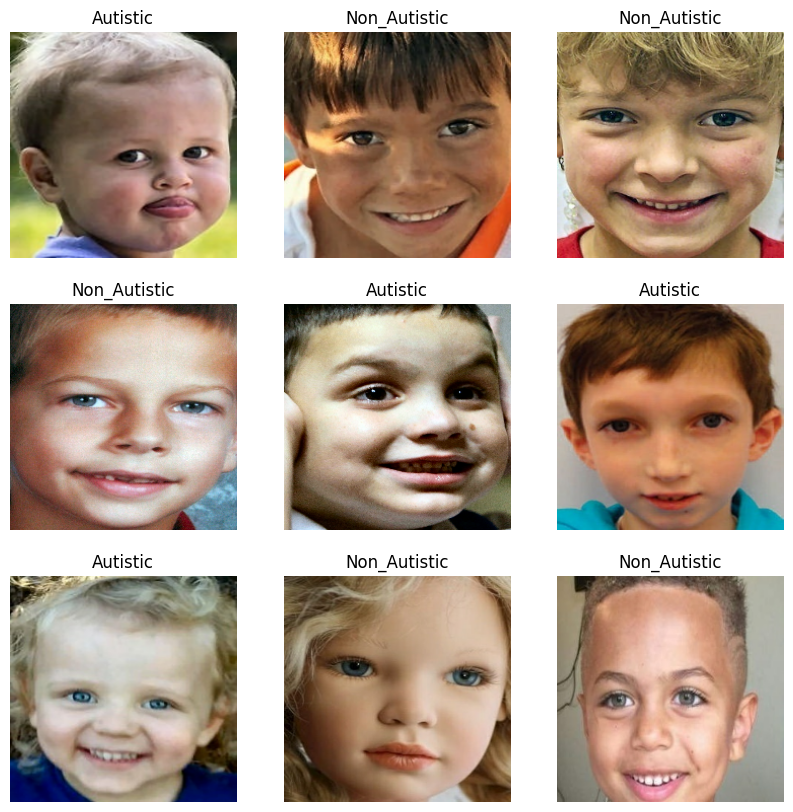

In [8]:
import matplotlib.pyplot as plt
# Visualize some training images
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [9]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 224, 224, 3)
(32,)


In [10]:
# Data Augmentation
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(224,
                                  224,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


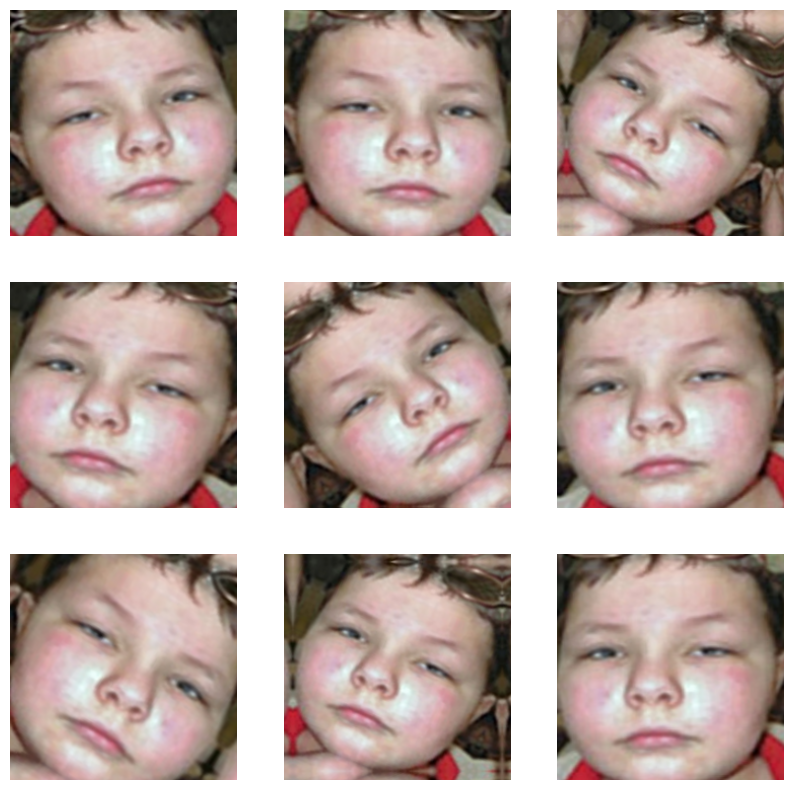

In [11]:
# Visualize some augmented images
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

Dataset Performance Optimization

In [12]:
# Configure the dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Simple CNN

In [13]:
num_classes = len(class_names)
# Build the model
model = Sequential([
  layers.Rescaling(1./255, input_shape=(224, 224, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

In [13]:
# Compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


In [14]:
model.summary() #Displays model architecture

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,446,498 (24.59 MB)

 Trainable params: 6,446,498 (24.59 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Train the model
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 165ms/step - accuracy: 0.6457 - loss: 0.6378 - val_accuracy: 0.6800 - val_loss: 0.5760
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 170ms/step - accuracy: 0.7650 - loss: 0.5062 - val_accuracy: 0.7300 - val_loss: 0.5447
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 223ms/step - accuracy: 0.8114 - loss: 0.4148 - val_accuracy: 0.7100 - val_loss: 0.6382
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 302ms/step - accuracy: 0.8748 - loss: 0.3081 - val_accuracy: 0.7700 - val_loss: 0.4710
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 247ms/step - accuracy: 0.9248 - loss: 0.2048 - val_accuracy: 0.7400 - val_loss: 0.6168
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 221ms/step - accuracy: 0.9516 - loss: 0.1342 - val_accuracy: 0.7000 - val_loss: 0.7917
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 27s 336ms/step - accuracy: 0.9799 - loss: 0.0680 - val_accuracy: 0.7600 - val_loss: 0.8128
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 26s 330ms/step - accuracy: 0.9945 - loss: 0.0271 - val_accu

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
📊 Simple CNN Autism Model Results
Accuracy: 0.7633333333333333
Precision: 0.7633450375572247
Recall: 0.7633333333333333
F1 Score: 0.7633307036744853
ROC AUC: 0.8481555555555556


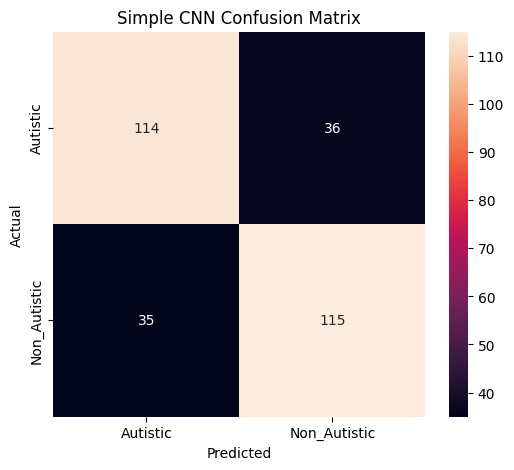

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
y_true, y_pred, y_prob = [], [], []

for images, labels in test_ds:
    preds = model.predict(images)

    y_true.extend(labels.numpy())          # FIXED
    y_pred.extend(np.argmax(preds, axis=1))
    y_prob.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("📊 Simple CNN Autism Model Results")
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))

roc_auc = roc_auc_score(tf.keras.utils.to_categorical(y_true), y_prob, multi_class='ovr')
print("ROC AUC:", roc_auc)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title("Simple CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
def evaluate_model(model, model_name):
    y_true, y_pred, y_prob = [], [], []

    for images, labels in test_ds:
        preds = model.predict(images)

        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))
        y_prob.extend(preds)

    y_true_np = np.array(y_true)
    y_pred_np = np.array(y_pred)
    y_prob_np = np.array(y_prob)

    print(f"\n📊 {model_name} Results")
    print("Accuracy:", accuracy_score(y_true_np, y_pred_np))
    print("Precision:", precision_score(y_true_np, y_pred_np, average='weighted'))
    print("Recall:", recall_score(y_true_np, y_pred_np, average='weighted'))
    print("F1 Score:", f1_score(y_true_np, y_pred_np, average='weighted'))

    roc_auc = roc_auc_score(
        tf.keras.utils.to_categorical(y_true_np),
        y_prob_np,
        multi_class='ovr'
    )
    print("ROC AUC:", roc_auc)

    cm = confusion_matrix(y_true_np, y_pred_np)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step

📊 Simple CNN Results
Accuracy: 0.7633333333333333
Precision: 0.7633450375572247
Recall: 0.7633333333333333
F1 Score: 0.7633307036744853
ROC AUC: 0.8481555555555556


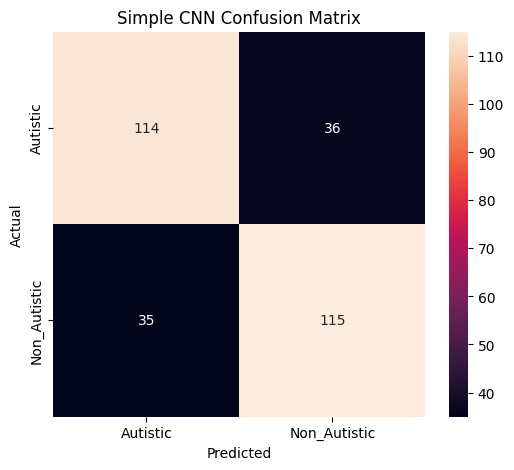

In [26]:
evaluate_model(model, "Simple CNN")

In [17]:
from tensorflow.keras.models import Model

In [18]:
# Create a new model that outputs the features from the Dense(128) layer
feature_extractor = Model(
    inputs=model.inputs,
    outputs=model.layers[-2].output   # Dense(128) layer
)

In [19]:
# Extract features for the training dataset
train_features = feature_extractor.predict(train_ds)


80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step


In [20]:
import pandas as pd

feature_names = [f"feature_{i+1}" for i in range(train_features.shape[1])]

In [21]:
df_features = pd.DataFrame(train_features, columns=feature_names)

In [22]:
df_features.to_csv("cnn_extracted_features.csv", index=False)

In [22]:
print(train_features[0])   # features of first image

[ 0.          2.0409956   0.          0.          0.          4.1288447
  0.          0.19977055  0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.15118425  0.6102707   0.          0.
  0.          0.          0.          1.1614394   0.          0.
  0.          4.853085    0.          0.          0.          0.
  3.8990564   6.5518456   0.          0.          0.          0.41659027
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          3.3447094   0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.17346889  1.8273247   3.7967937   0.
  0.67685723 10.281906    0.          3.5576344   0.          0.
  0.          0.          6.6012435   0.          0.          0.
  0.          0.          0.          6.1890283   0.          0.
  0.          0.          5.9820256   0.          0.          0.
  0.      

In [14]:
# Save the model
model.save("asd_cnn_model1.keras")

In [22]:
model.save("asd_cnn_model.h5")  # HDF5 format


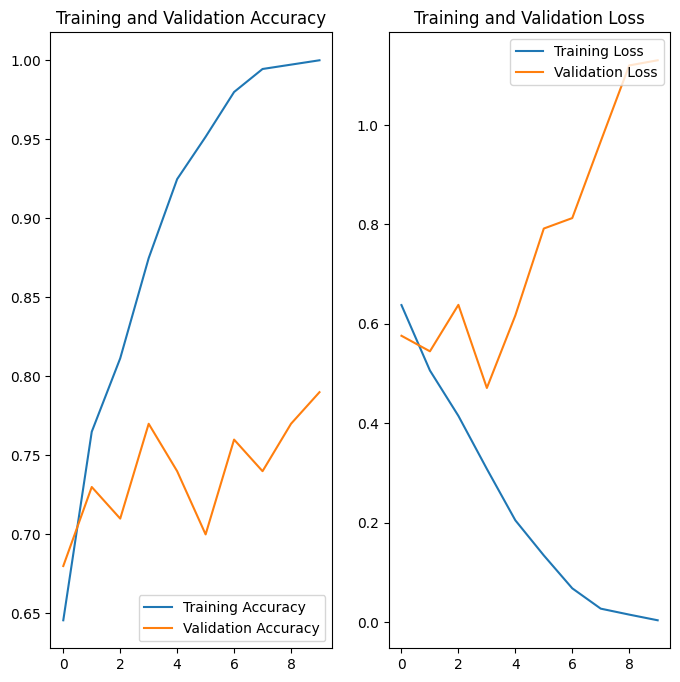

In [21]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

MobileNetV2

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2

num_classes = len(class_names)  # Number of classes in your dataset
input_shape = (224, 224, 3)    # Adjust according to your images

# Load MobileNetV2 without top layers and with pre-trained weights
base_model = MobileNetV2(input_shape=input_shape,
                         include_top=False,
                         weights='imagenet')

# Freeze the base model so we don't train pre-trained weights
base_model.trainable = False

# Add custom classification head
inputs = tf.keras.Input(shape=input_shape)
x = layers.Rescaling(1./255)(inputs)  # normalize input
x = base_model(x, training=False)      # pass through MobileNetV2
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(num_classes)(x)  # logits, not softmax
model_mobilenet = Model(inputs, outputs)

# Compile the model
model_mobilenet.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model_mobilenet.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
epochs = 10
history_mobilenet = model_mobilenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 28s 289ms/step - accuracy: 0.7185 - loss: 0.5669 - val_accuracy: 0.7400 - val_loss: 0.5405
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 263ms/step - accuracy: 0.7906 - loss: 0.4401 - val_accuracy: 0.7100 - val_loss: 0.5618
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 267ms/step - accuracy: 0.8244 - loss: 0.3873 - val_accuracy: 0.7300 - val_loss: 0.5451
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 22s 271ms/step - accuracy: 0.8366 - loss: 0.3633 - val_accuracy: 0.7500 - val_loss: 0.5219
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 269ms/step - accuracy: 0.8571 - loss: 0.3174 - val_accuracy: 0.7200 - val_loss: 0.5230
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 22s 276ms/step - accuracy: 0.8846 - loss: 0.2766 - val_accuracy: 0.7000 - val_loss: 0.6016
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 302ms/step - accuracy: 0.9079 - loss: 0.2359 - val_accuracy: 0.7400 - val_loss: 0.5204
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 22s 274ms/step - accuracy: 0.9217 - loss: 0.2150 - val_accu

In [23]:
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step

📊 MobileNet Results
Accuracy: 0.82
Precision: 0.8214285714285715
Recall: 0.82
F1 Score: 0.8197997775305895
ROC AUC: 0.8895333333333333


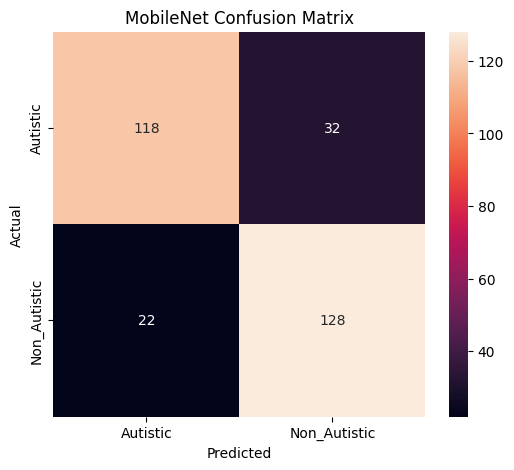

In [24]:
evaluate_model(model_mobilenet, "MobileNet")

In [25]:
model.save("mobilenet.keras")

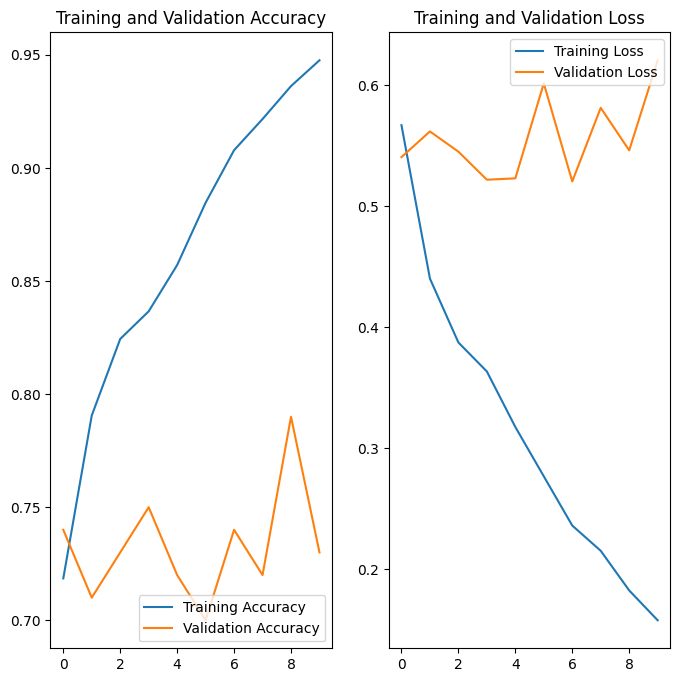

In [26]:
acc = history_mobilenet.history['accuracy']
val_acc = history_mobilenet.history['val_accuracy']

loss = history_mobilenet.history['loss']
val_loss = history_mobilenet.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

VGG16

In [30]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16

num_classes = len(class_names)  # Number of classes in your dataset
input_shape = (224, 224, 3)    # Image size

# Load VGG16 without top layers
base_model = VGG16(input_shape=input_shape,
                   include_top=False,
                   weights='imagenet')
base_model.trainable = False  # Freeze base model

# Add custom classification head
inputs = tf.keras.Input(shape=input_shape)
x = layers.Rescaling(1./255)(inputs)  # normalize input
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(num_classes)(x)  # logits
model_vgg16 = Model(inputs, outputs)

# Compile the model
model_vgg16.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model_vgg16.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,610 (56.38 MB)

 Trainable params: 65,922 (257.51 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [31]:
# Train the model
epochs = 5
history_vgg16 = model_vgg16.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 210s 3s/step - accuracy: 0.6232 - loss: 0.6437 - val_accuracy: 0.6900 - val_loss: 0.5698
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 218s 3s/step - accuracy: 0.7350 - loss: 0.5473 - val_accuracy: 0.7000 - val_loss: 0.5491
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 212s 3s/step - accuracy: 0.7496 - loss: 0.5115 - val_accuracy: 0.7000 - val_loss: 0.5410
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 209s 3s/step - accuracy: 0.7701 - loss: 0.4935 - val_accuracy: 0.6800 - val_loss: 0.5352
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 210s 3s/step - accuracy: 0.7776 - loss: 0.4726 - val_accuracy: 0.7600 - val_loss: 0.5442


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 833ms/step

📊 VGG16 Results
Accuracy: 0.7766666666666666
Precision: 0.778760467511531
Recall: 0.7766666666666666
F1 Score: 0.7762465073304315
ROC AUC: 0.8616666666666666


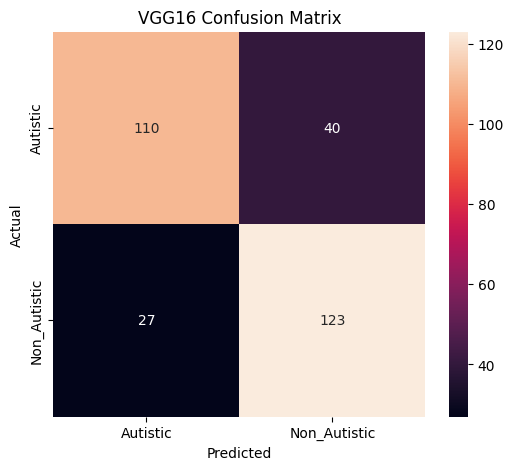

In [32]:
evaluate_model(model_vgg16, "VGG16")

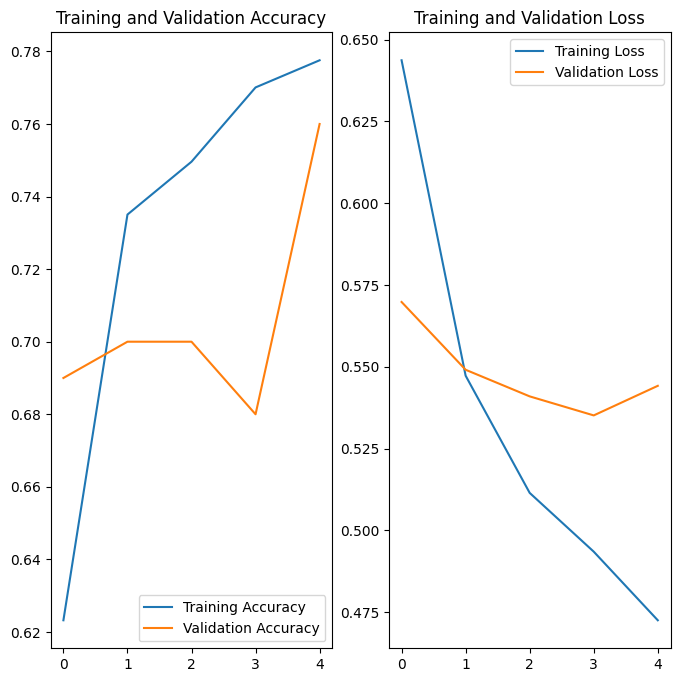

In [33]:
acc = history_vgg16.history['accuracy']
val_acc = history_vgg16.history['val_accuracy']

loss = history_vgg16.history['loss']
val_loss = history_vgg16.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

ResNet50

In [34]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50

num_classes = len(class_names)   # Number of classes in your dataset
input_shape = (224, 224, 3)      # Image size

# Load ResNet50 without the top layers
base_model = ResNet50(input_shape=input_shape,
                      include_top=False,
                      weights='imagenet')
base_model.trainable = False  # Freeze base model

# Add custom classification head
inputs = tf.keras.Input(shape=input_shape)
x = layers.Rescaling(1./255)(inputs)         # normalize pixels
x = base_model(x, training=False)            # pass through ResNet base
x = layers.GlobalAveragePooling2D()(x)       # reduce feature maps
x = layers.Dense(128, activation='relu')(x)  # fully connected layer
outputs = layers.Dense(num_classes)(x)       # logits (no softmax here)
model_resnet = Model(inputs, outputs)

In [35]:
model_resnet.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [36]:
model_resnet.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,242 (90.98 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [37]:
epochs = 10
history_resnet = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 73s 875ms/step - accuracy: 0.5098 - loss: 0.7279 - val_accuracy: 0.6600 - val_loss: 0.6475
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 73s 908ms/step - accuracy: 0.5689 - loss: 0.6909 - val_accuracy: 0.6600 - val_loss: 0.6331
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 74s 931ms/step - accuracy: 0.6114 - loss: 0.6582 - val_accuracy: 0.6800 - val_loss: 0.6202
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 76s 955ms/step - accuracy: 0.6047 - loss: 0.6665 - val_accuracy: 0.5400 - val_loss: 0.6746
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 78s 982ms/step - accuracy: 0.6051 - loss: 0.6620 - val_accuracy: 0.6600 - val_loss: 0.6433
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.6000 - loss: 0.6560 - val_accuracy: 0.6800 - val_loss: 0.6058
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.6307 - loss: 0.6356 - val_accuracy: 0.6900 - val_loss: 0.5979
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 80s 995ms/step - accuracy: 0.6303 - loss: 0.6393 - val_accuracy:

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 808ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 822ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 842ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 845ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 840ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 853ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 848ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 880ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

📊 ReseNet50 Results
Accuracy: 0.6966666666666667
Precision: 0.709407978798921
Recall: 0.6966666666666667
F1 Score: 0.691981360923379
ROC AUC: 0.7580444444444445


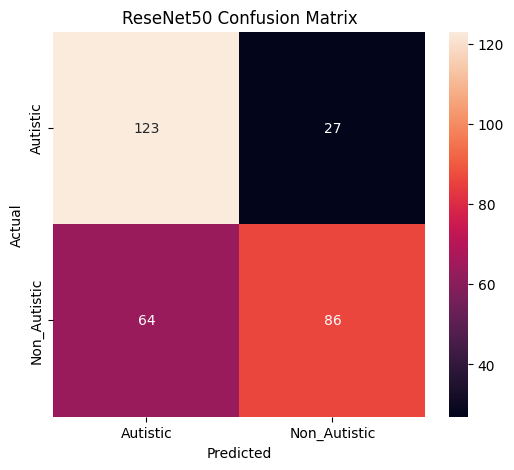

In [38]:
evaluate_model(model_resnet, "ReseNet50")

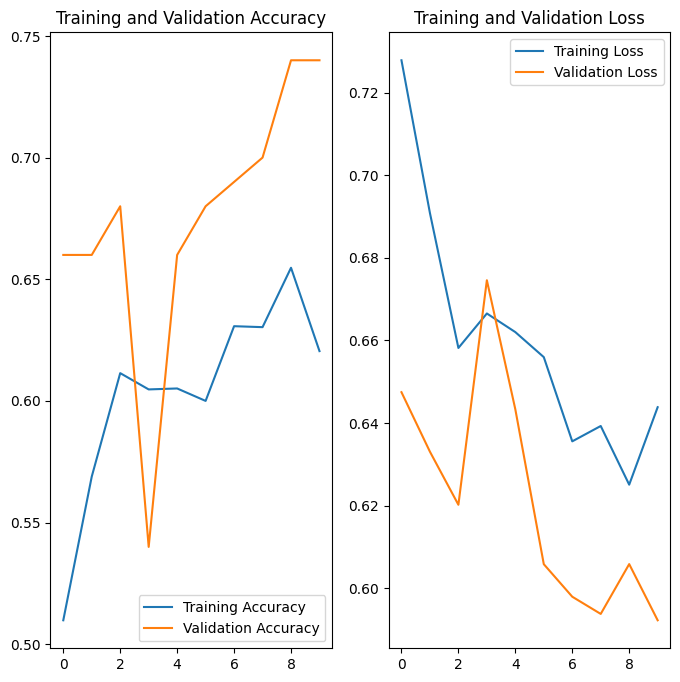

In [39]:
acc = history_resnet.history['accuracy']
val_acc = history_resnet.history['val_accuracy']

loss = history_resnet.history['loss']
val_loss = history_resnet.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

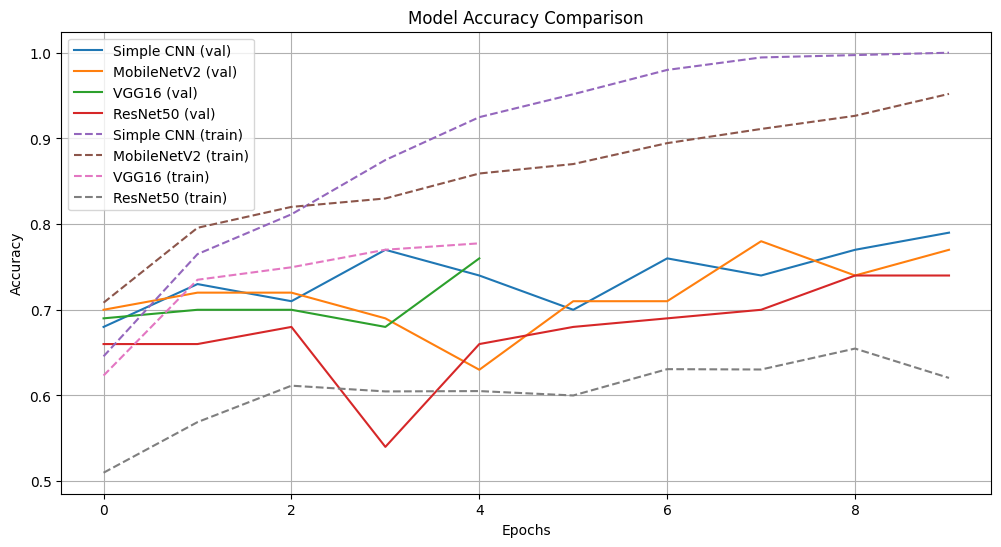

In [40]:
import matplotlib.pyplot as plt

# List of histories (change names to match your variables)
histories = {
    "Simple CNN": history,
    "MobileNetV2": history_mobilenet,
    "VGG16": history_vgg16,
    "ResNet50": history_resnet,
}

plt.figure(figsize=(12, 6))

# Plot validation accuracy for each model
for name, hist in histories.items():
    plt.plot(hist.history['val_accuracy'], label=f'{name} (val)')

# Optionally also plot training accuracy
for name, hist in histories.items():
    plt.plot(hist.history['accuracy'], linestyle="--", label=f'{name} (train)')

plt.title("Model Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [41]:
import json

with open("class_names.json", "r") as f:
    class_names = json.load(f)

In [42]:
print("Model output shape:", model.output_shape)
print("Number of class names:", len(class_names))
print("Class names:", class_names)


Model output shape: (None, 2)
Number of class names: 2
Class names: ['Autistic', 'Non_Autistic']


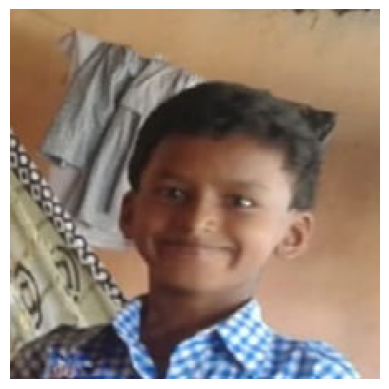

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
This image most likely belongs to Non_Autistic with a 99.94% confidence.


In [34]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load the saved model
model = tf.keras.models.load_model(
    r"C:\Users\HP\OneDrive\Desktop\ASD\ASD\asd_cnn_model1.keras"
)

# Load and display image
img = tf.keras.utils.load_img(
    r"C:\Users\HP\OneDrive\Pictures\Test\Test4.jpg",
    target_size=(224, 224)
)

plt.imshow(img)
plt.axis('off')
plt.show()

# Convert image to array
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # batch of 1

# Predict
predictions = model.predict(img_array)

# Convert logits to probabilities
score = tf.nn.softmax(predictions[0])

# Display result
print(
    "This image most likely belongs to {} with a {:.2f}% confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)
